# FULL Clustering Pipeline Notebook (Original Logic Preserved)

Notebook này:
- Giữ nguyên 100% pipeline gốc
- Không lược bỏ bất kỳ figure nào
- Fix lỗi exit()
- Fix DBSCAN eps hardcode
- Fix heatmap magnitude distortion
- Fix sai tên file error message


In [213]:
import sys

In [214]:
# 1. IMPORT & SETUP

In [215]:
import sys
import pandas as pd
import numpy as np
import time
import warnings
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import hdbscan

from sklearn.cluster import HDBSCAN
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from hdbscan import HDBSCAN
try:
    # Hỗ trợ cho scikit-learn >= 1.3
    from sklearn.cluster import HDBSCAN
except ImportError:
    # Nếu dùng scikit-learn cũ, bạn cần chạy: pip install hdbscan
    from hdbscan import HDBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score
)
from sklearn.neighbors import NearestNeighbors

# Cấu hình vẽ đồ thị cho Paper
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.2)
warnings.filterwarnings("ignore")
RANDOM_STATE = 42

In [216]:
# 2. LOAD DATA

In [217]:
print("--- 1. Loading Data ---")
try:
    # Đảm bảo file cs-training.csv nằm cùng thư mục với code
    df = pd.read_csv(r"D:/Clustering/Clustering/Clustering/cs-training.csv")
    if df.columns[0].startswith('Unnamed'):
        df = df.iloc[:, 1:]
except FileNotFoundError:
    print("Error: File 'cs-training.csv' không tồn tại. Vui lòng kiểm tra lại đường dẫn.")
    exit()

TARGET_COL = "SeriousDlqin2yrs"
if TARGET_COL in df.columns:
    y_true_full = df[TARGET_COL]
    X_full = df.drop(columns=[TARGET_COL])
else:
    print(f"Error: Không tìm thấy cột mục tiêu '{TARGET_COL}'.")
    exit()

print(f"Original Shape: {df.shape}")

--- 1. Loading Data ---
Original Shape: (150000, 11)


In [218]:
# 3. FIGURE A: RAW DATA DIAGNOSTICS (EDA)

--- 2. Generating EDA Visualizations ---


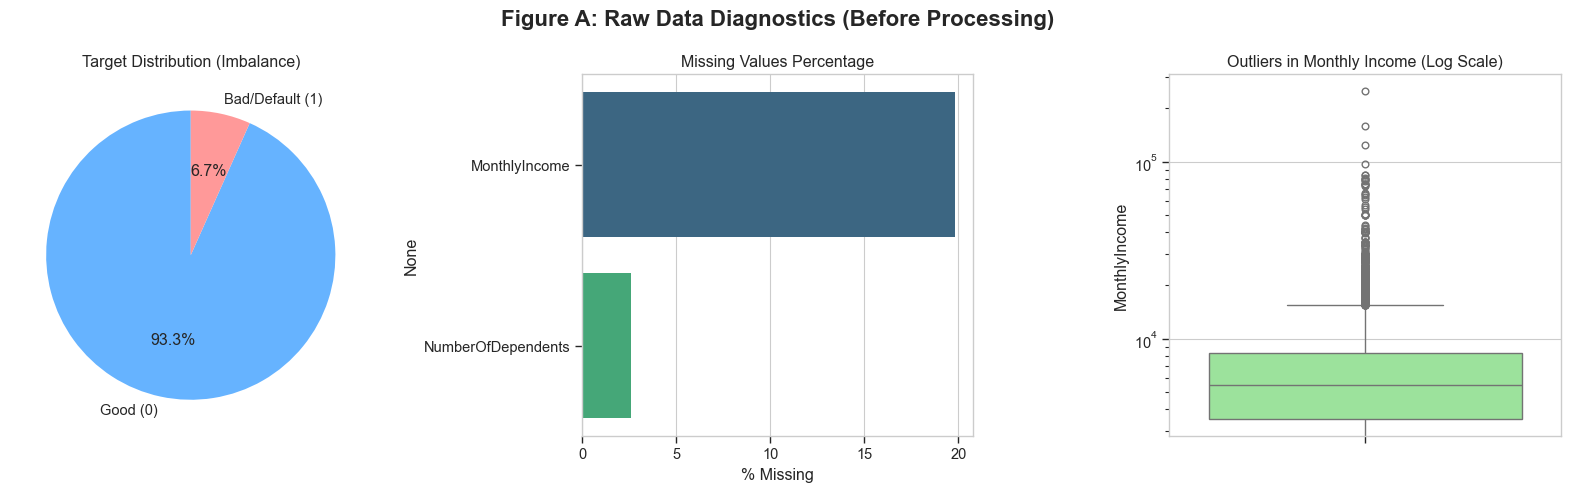

In [219]:
# =========================================
# 3. FIGURE A: RAW DATA DIAGNOSTICS (EDA)
# =========================================
print("--- 2. Generating EDA Visualizations ---")
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 3.1 Phân phối Nhãn (Ground Truth)
target_counts = df[TARGET_COL].value_counts()
axes[0].pie(target_counts, labels=['Good (0)', 'Bad/Default (1)'], 
            autopct='%1.1f%%', colors=['#66b3ff', '#ff9999'], startangle=90)
axes[0].set_title("Target Distribution (Imbalance)")

# 3.2 Giá trị khuyết
missing_data = df.isnull().mean() * 100
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)
if not missing_data.empty:
    sns.barplot(x=missing_data.values, y=missing_data.index, ax=axes[1], palette="viridis")
    axes[1].set_xlabel("% Missing")
    axes[1].set_title("Missing Values Percentage")
else:
    axes[1].text(0.5, 0.5, 'No Missing Values', ha='center')

# 3.3 Ngoại lai (Boxplot)
sns.boxplot(y=df['MonthlyIncome'].dropna().sample(min(10000, len(df))), ax=axes[2], color='lightgreen')
axes[2].set_yscale('log') 
axes[2].set_title("Outliers in Monthly Income (Log Scale)")

plt.suptitle("Figure A: Raw Data Diagnostics (Before Processing)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig("figA_raw_data_diagnostics.png", dpi=150)
plt.show()
plt.close()


In [220]:
# 4. PREPROCESSING

In [221]:
# =========================================
# 4. PREPROCESSING
# =========================================
print("--- 3. Preprocessing Data ---")
X_full["MonthlyIncome"] = X_full["MonthlyIncome"].fillna(X_full["MonthlyIncome"].median())
X_full["NumberOfDependents"] = X_full["NumberOfDependents"].fillna(X_full["NumberOfDependents"].median())

# Xử lý ngoại lai: Clipping 1% và 99%
lower = X_full.quantile(0.01)
upper = X_full.quantile(0.99)
X_full = X_full.clip(lower=lower, upper=upper, axis=1)

--- 3. Preprocessing Data ---


In [222]:
# 5. FIGURE 1: CORRELATION HEATMAP

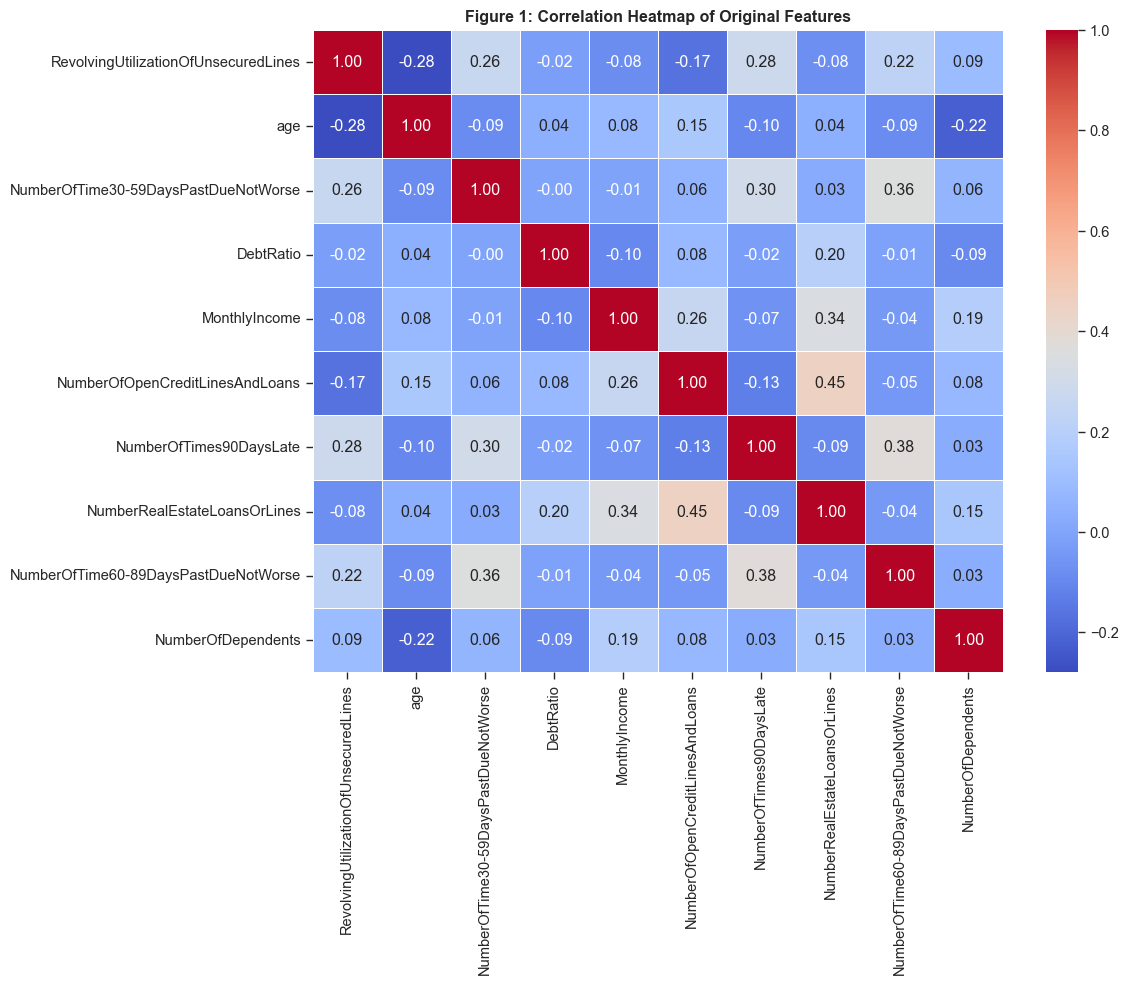

In [223]:
# =========================================
# 5. FIGURE 1: CORRELATION HEATMAP
# =========================================
plt.figure(figsize=(12, 10))
corr_matrix = X_full.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Figure 1: Correlation Heatmap of Original Features", fontweight='bold')
plt.tight_layout()
plt.savefig("fig1_correlation.png", dpi=150)
plt.show()
plt.close()


In [224]:
# 6. SCALING & PCA

In [225]:
# =========================================
# 6. SCALING & PCA
# =========================================
print("--- 4. Scaling & PCA ---")
scaler = StandardScaler()
X_scaled_full = scaler.fit_transform(X_full)

pca = PCA(n_components=0.95, random_state=RANDOM_STATE)
X_pca_full = pca.fit_transform(X_scaled_full)
print(f"PCA components retained: {pca.n_components_} (giữ 95% phương sai)")

--- 4. Scaling & PCA ---
PCA components retained: 9 (giữ 95% phương sai)


In [226]:
# 7. SAMPLING (TỐI ƯU BỘ NHỚ)

In [227]:
SAMPLE_SIZE = 10000
np.random.seed(RANDOM_STATE)
sample_indices = np.random.choice(X_pca_full.shape[0], SAMPLE_SIZE, replace=False)

X_final = X_pca_full[sample_indices]
y_true_final = y_true_full.iloc[sample_indices].reset_index(drop=True)
X_original_sample = X_full.iloc[sample_indices].reset_index(drop=True)
print(f"Sampled Shape for Clustering: {X_final.shape}")

Sampled Shape for Clustering: (10000, 9)


--- Generating PCA Ground Truth Plot ---


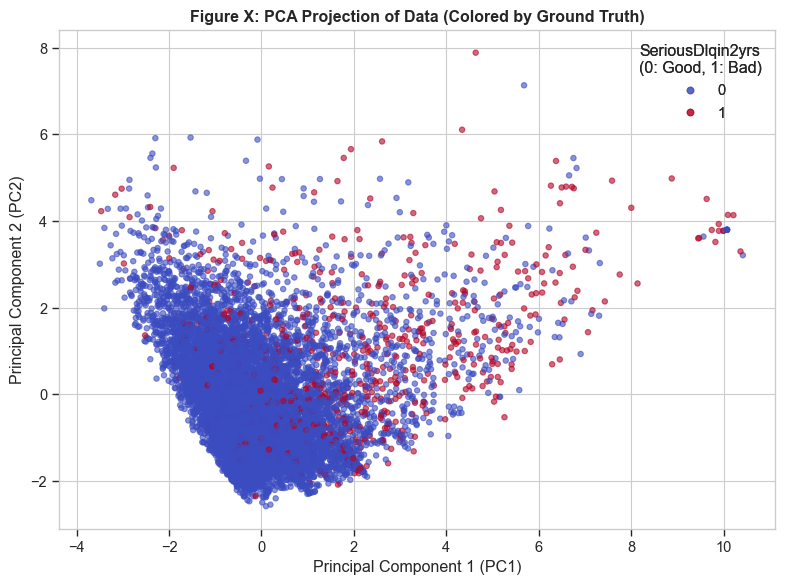

In [228]:
# =========================================
# 8. FIGURE X: PCA TRÊN DỮ LIỆU GỐC (GROUND TRUTH)
# =========================================
print("--- Generating PCA Ground Truth Plot ---")
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_final[:, 0], X_final[:, 1], c=y_true_final, cmap='coolwarm', s=15, alpha=0.6)
plt.title("Figure X: PCA Projection of Data (Colored by Ground Truth)", fontweight='bold')
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
legend = plt.legend(*scatter.legend_elements(), title="SeriousDlqin2yrs\n(0: Good, 1: Bad)", loc="upper right")
plt.gca().add_artist(legend)
plt.tight_layout()
plt.savefig("figX_pca_ground_truth.png", dpi=150)
plt.show()
plt.close()


In [229]:
# 8. FIGURE 2 & 3: FINDING BEST K

--- 5. Finding Optimal K ---


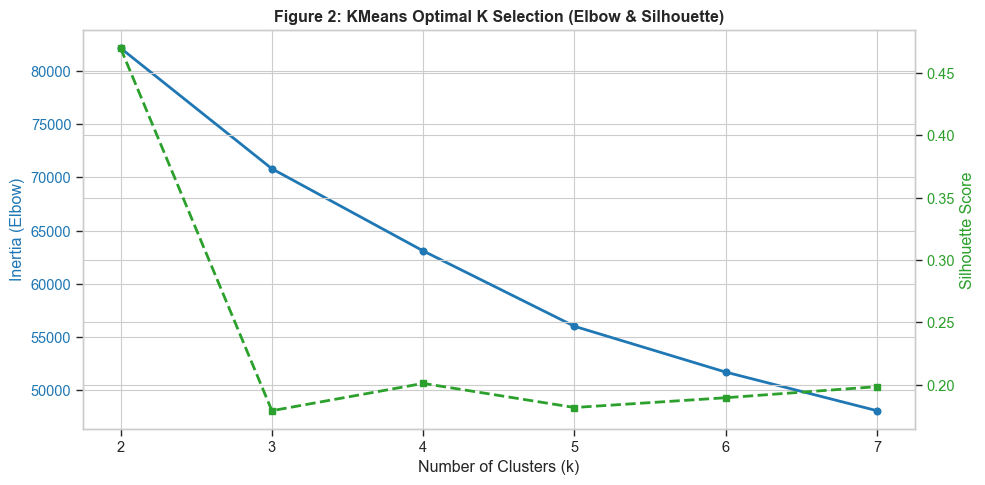

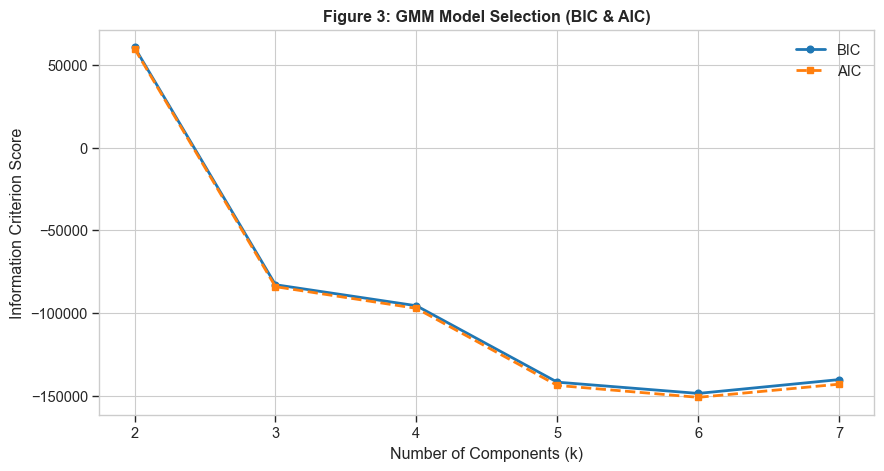

In [230]:
# =========================================
# 9. FIGURE 2 & 3: FINDING BEST K
# =========================================
print("--- 5. Finding Optimal K ---")
k_range = range(2, 8)
inertias, silhouettes, bics, aics = [], [], [], []

for k in k_range:
    kmeans_tmp = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    labels_tmp = kmeans_tmp.fit_predict(X_final)
    inertias.append(kmeans_tmp.inertia_)
    silhouettes.append(silhouette_score(X_final, labels_tmp))
    
    gmm_tmp = GaussianMixture(n_components=k, random_state=RANDOM_STATE)
    gmm_tmp.fit(X_final)
    bics.append(gmm_tmp.bic(X_final))
    aics.append(gmm_tmp.aic(X_final))


# Fig 2: KMeans Selection
fig, ax1 = plt.subplots(figsize=(10, 5))
color = 'tab:blue'
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (Elbow)', color=color)
ax1.plot(k_range, inertias, marker='o', color=color, linewidth=2, label='Inertia')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:green'
ax2.set_ylabel('Silhouette Score', color=color)
ax2.plot(k_range, silhouettes, marker='s', linestyle='--', color=color, linewidth=2, label='Silhouette')
ax2.tick_params(axis='y', labelcolor=color)
plt.title("Figure 2: KMeans Optimal K Selection (Elbow & Silhouette)", fontweight='bold')
fig.tight_layout()
plt.savefig("fig2_kmeans_selection.png", dpi=150)
plt.show()
plt.close()

# Fig 3: GMM Selection
plt.figure(figsize=(10, 5))
plt.plot(k_range, bics, marker='o', label='BIC', linewidth=2)
plt.plot(k_range, aics, marker='s', linestyle='--', label='AIC', linewidth=2)
plt.xlabel('Number of Components (k)')
plt.ylabel('Information Criterion Score')
plt.title("Figure 3: GMM Model Selection (BIC & AIC)", fontweight='bold')
plt.legend()
plt.savefig("fig3_gmm_selection.png", dpi=150)
plt.show()
plt.close()

In [231]:
# 9. FIGURE B: k-NN DISTANCE (DBSCAN EPS)

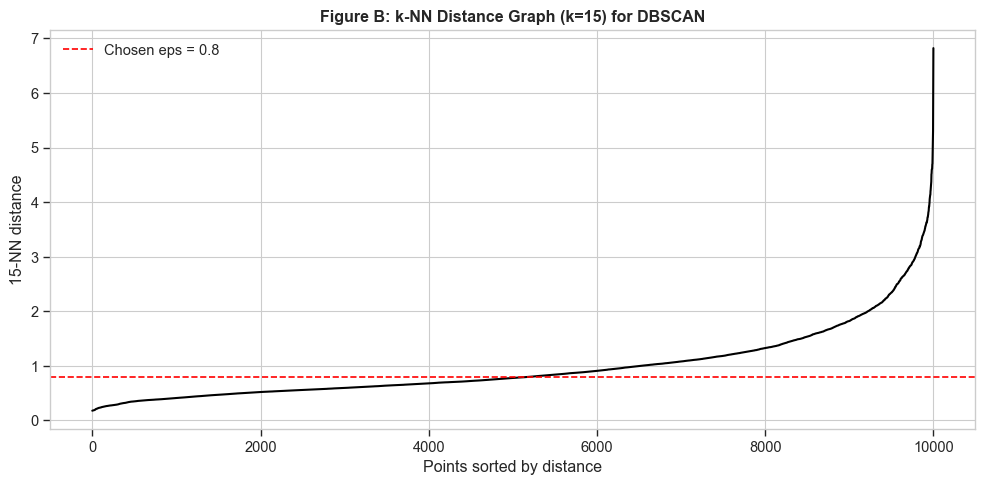

In [232]:
# =========================================
# 10. FIGURE B: k-NN DISTANCE (DBSCAN EPS)
# =========================================
minPts = 15
neighbors = NearestNeighbors(n_neighbors=minPts)
neighbors_fit = neighbors.fit(X_final)
distances, indices = neighbors_fit.kneighbors(X_final)
distances = np.sort(distances[:, minPts-1], axis=0)

plt.figure(figsize=(10, 5))
plt.plot(distances, color='black', linewidth=1.5)
plt.title(f"Figure B: k-NN Distance Graph (k={minPts}) for DBSCAN", fontweight='bold')
plt.xlabel("Points sorted by distance")
plt.ylabel(f"{minPts}-NN distance")
plt.axhline(y=0.8, color='r', linestyle='--', label='Chosen eps = 0.8')
plt.legend()
plt.tight_layout()
plt.savefig("figB_knn_distance.png", dpi=150)
plt.show()
plt.close()


In [233]:
# 10. RUN FINAL MODELS (K=2)

In [234]:
K_COMPONENTS = 3
print(f"--- 6. Running Final Models (K={K_COMPONENTS}) ---")
final_results = []
model_labels = {}

def evaluate_model(name, X, labels, y_true, runtime):
    # 1. TÍNH TỶ LỆ NHIỄU (Cho thuật toán như DBSCAN, HDBSCAN)
    noise_count = np.sum(labels == -1)
    noise_pct = (noise_count / len(labels)) * 100
    
    # 2. Loại bỏ nhiễu (-1) trước khi đánh giá chỉ số nội bộ để tránh lỗi
    mask = labels != -1
    core_samples = X[mask]
    core_labels = labels[mask]
    n_clusters = len(set(core_labels))
    
    if n_clusters > 1:
        sil = silhouette_score(core_samples, core_labels)
        dbi = davies_bouldin_score(core_samples, core_labels)
        chi = calinski_harabasz_score(core_samples, core_labels)
    else:
        sil, dbi, chi = np.nan, np.nan, np.nan

    # 3. ARI luôn đánh giá trên toàn bộ dữ liệu
    ari = adjusted_rand_score(y_true, labels)
    
    # 4. Lưu kết quả đúng chuẩn format để vẽ Figure C
    final_results.append({
        "Model": name, 
        "Noise (%)": round(noise_pct, 2),  
        "Silhouette": sil, 
        "DBI": dbi, 
        "CHI": chi, 
        "ARI": ari, 
        "Time(s)": round(runtime, 4)
    })

# Tích hợp trực tiếp HDBSCAN vào đây
models_to_run = {
    'KMeans': KMeans(n_clusters=K_COMPONENTS, n_init=20, random_state=RANDOM_STATE),
    'Hierarchical': AgglomerativeClustering(n_clusters=K_COMPONENTS),
    'DBSCAN': DBSCAN(eps=0.8, min_samples=15),
    'GMM': GaussianMixture(n_components=K_COMPONENTS, random_state=RANDOM_STATE),
    'HDBSCAN': hdbscan.HDBSCAN(min_cluster_size=15, min_samples=5) # <--- BỔ SUNG HDBSCAN
}

for name, model in models_to_run.items():
    start = time.time()
    model_labels[name] = model.fit_predict(X_final)
    evaluate_model(name, X_final, model_labels[name], y_true_final, time.time() - start)

--- 6. Running Final Models (K=3) ---


--- 7. Generating Visual Comparisons ---


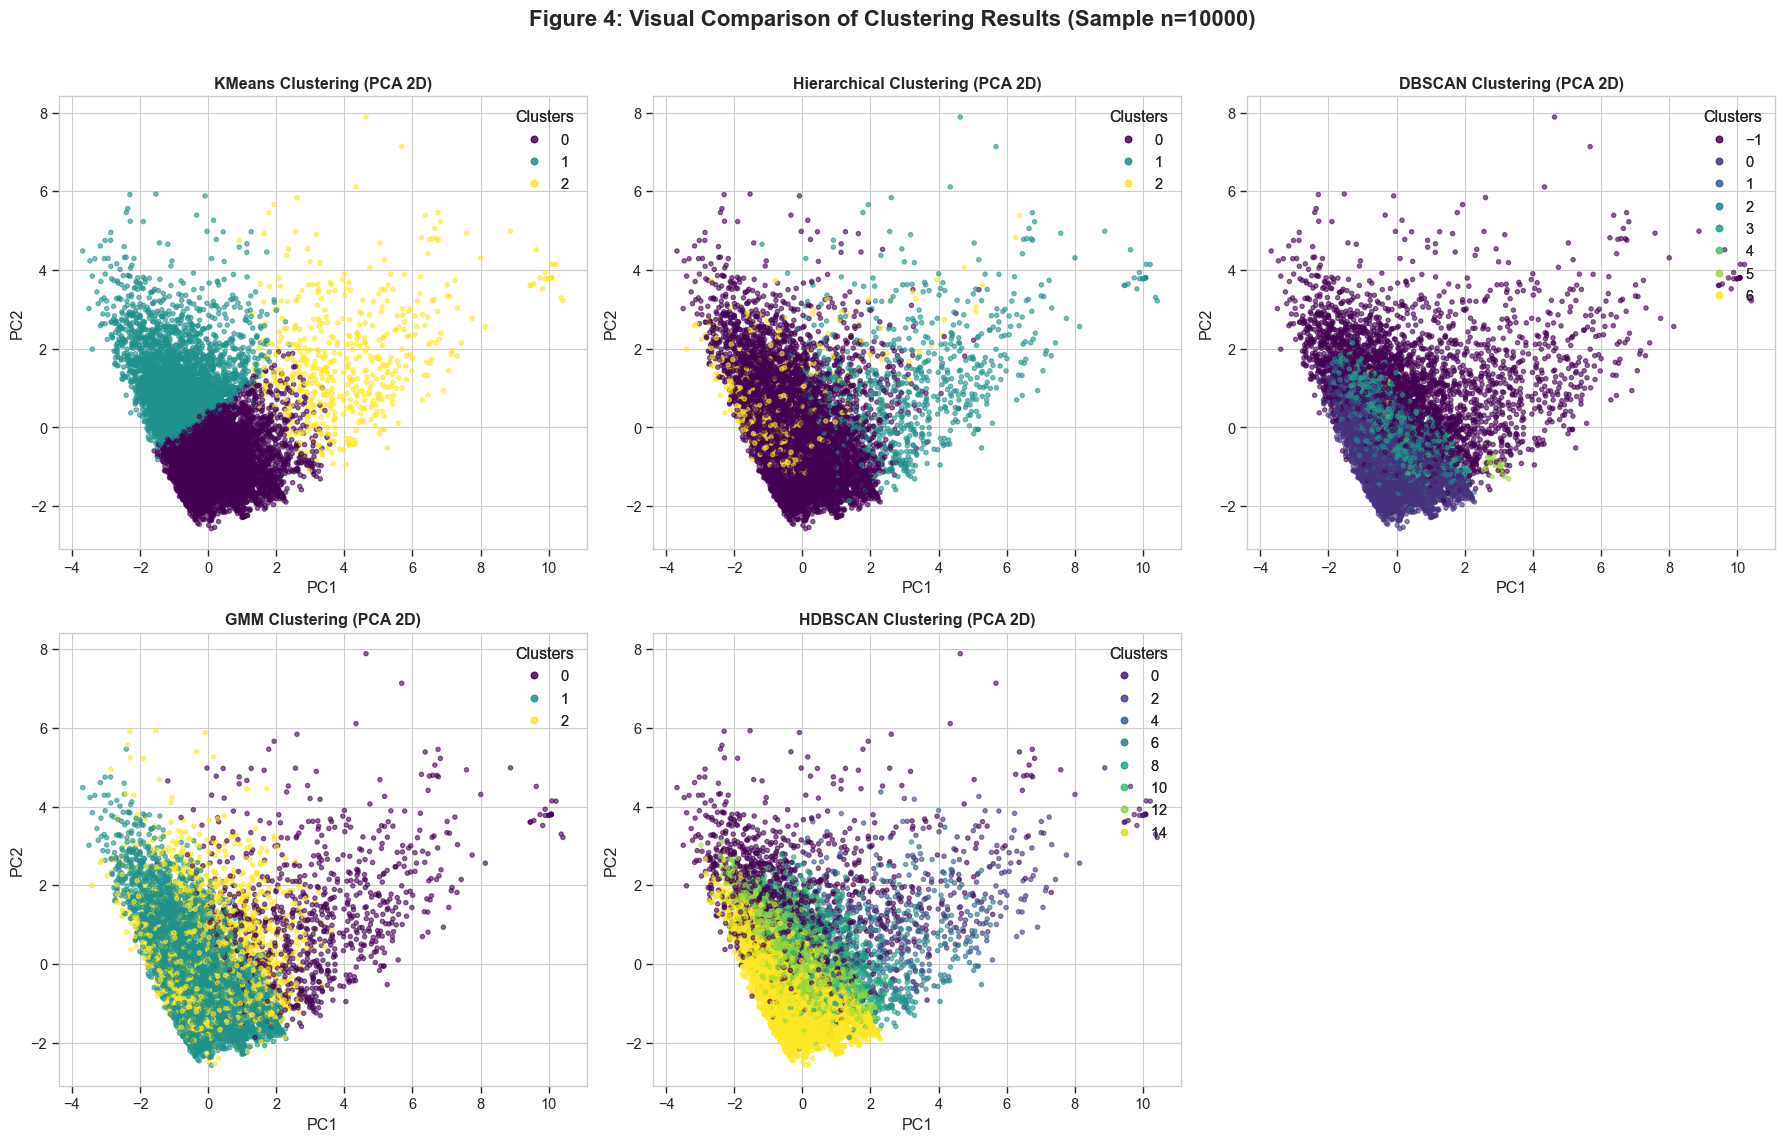

In [235]:
# =========================================
# 12. FIGURE 4: 2D CLUSTER PROJECTION
# =========================================
print("--- 7. Generating Visual Comparisons ---")
# Nâng layout lên 2x3 vì bây giờ có 5 model (KMeans, GMM, Hierarchical, DBSCAN, HDBSCAN)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()
plot_models = list(models_to_run.keys()) 

for i, model_name in enumerate(plot_models):
    labels = model_labels[model_name]
    ax = axes[i]
    scatter = ax.scatter(X_final[:, 0], X_final[:, 1], c=labels, cmap='viridis', s=10, alpha=0.6)
    ax.set_title(f"{model_name} Clustering (PCA 2D)", fontweight='bold')
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    legend = ax.legend(*scatter.legend_elements(), title="Clusters", loc="upper right")
    ax.add_artist(legend)

# Tắt hiển thị khung biểu đồ thừa (ô thứ 6) nếu chỉ có 5 model
if len(plot_models) < len(axes):
    for j in range(len(plot_models), len(axes)):
        axes[j].axis('off')

plt.suptitle(f"Figure 4: Visual Comparison of Clustering Results (Sample n={SAMPLE_SIZE})", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.savefig("fig4_cluster_comparison.png", dpi=150)
plt.show()
plt.close()

In [236]:
# 11. FIGURE 4: 2D CLUSTER PROJECTION

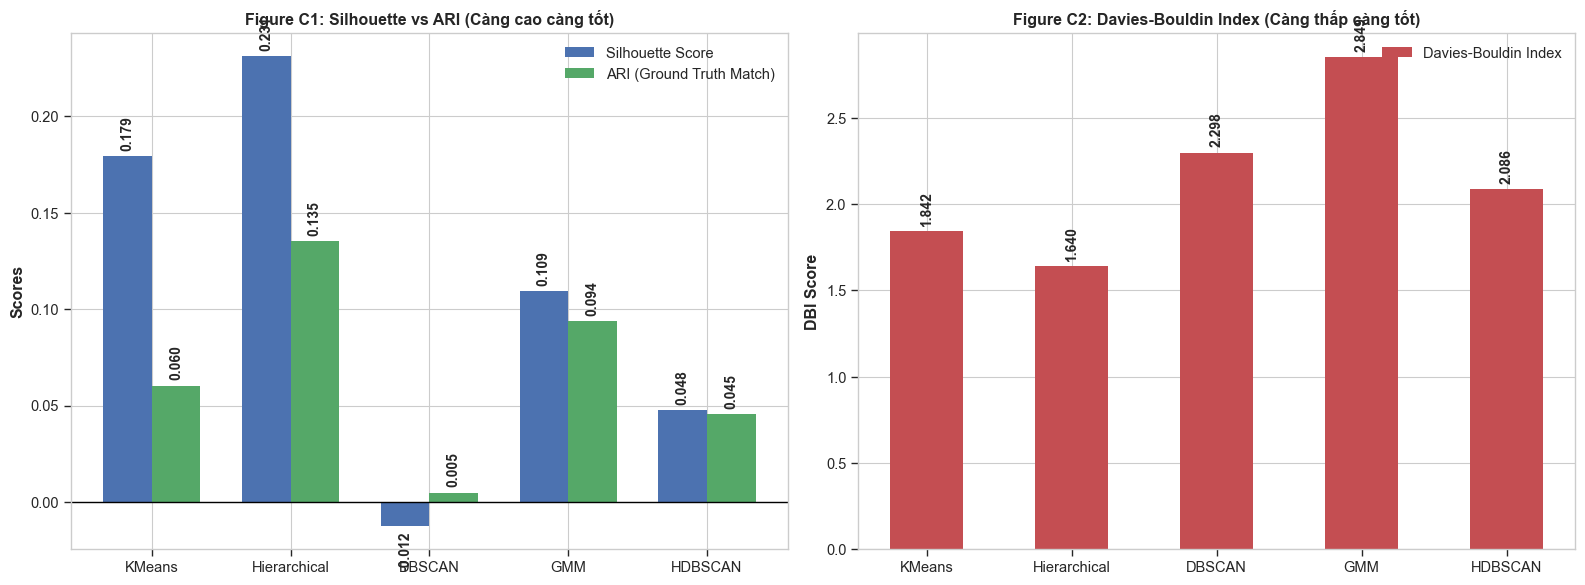

In [237]:
# =========================================
# 13. FIGURE C: MODEL PERFORMANCE (Tách 2 biểu đồ, Fix dính chữ)
# =========================================
df_metrics = pd.DataFrame(final_results)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
x = np.arange(len(df_metrics['Model']))
width = 0.35  

# Cột 1: Silhouette vs ARI
ax1 = axes[0]
rects1 = ax1.bar(x - width/2, df_metrics['Silhouette'], width, label='Silhouette Score', color='#4c72b0')
rects2 = ax1.bar(x + width/2, df_metrics['ARI'], width, label='ARI (Ground Truth Match)', color='#55a868')
ax1.set_ylabel('Scores', fontweight='bold')
ax1.set_title('Figure C1: Silhouette vs ARI (Càng cao càng tốt)', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(df_metrics['Model'])
ax1.axhline(0, color='black', linewidth=1)
ax1.legend(loc='upper right')

# Cột 2: DBI
ax2 = axes[1]
rects3 = ax2.bar(x, df_metrics['DBI'], width=0.5, label='Davies-Bouldin Index', color='#c44e52')
ax2.set_ylabel('DBI Score', fontweight='bold')
ax2.set_title('Figure C2: Davies-Bouldin Index (Càng thấp càng tốt)', fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(df_metrics['Model'])
ax2.legend(loc='upper right')

# Hàm dán nhãn xoay 90 độ, thêm xử lý bỏ qua NaN (phòng trường hợp thuật toán gộp thành 1 cụm)
def autolabel(rects, ax):
    for rect in rects:
        height = rect.get_height()
        if pd.notnull(height) and not np.isnan(height):
            va = 'bottom' if height >= 0 else 'top'
            offset = 4 if height >= 0 else -4
            ax.annotate(f'{height:.3f}', 
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, offset), textcoords="offset points", 
                        ha='center', va=va, fontsize=10, fontweight='bold', rotation=90)

autolabel(rects1, ax1)
autolabel(rects2, ax1)
autolabel(rects3, ax2)

plt.tight_layout()
plt.savefig("figC_model_comparison_clean.png", dpi=150)
plt.show()
plt.close()

In [238]:
# 12. FIGURE C: MODEL PERFORMANCE BAR CHART

--- 8. Profiling Clusters ---


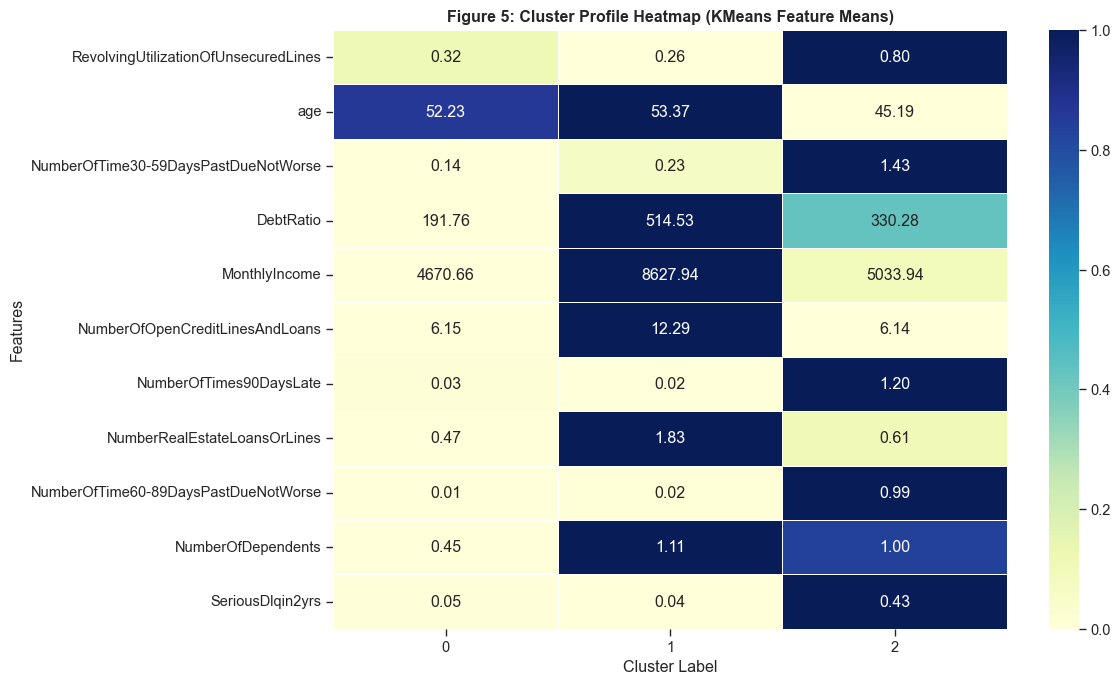

In [239]:
# =========================================
# 14. FIGURE 5: CLUSTER PROFILING
# =========================================
print("--- 8. Profiling Clusters ---")
df_profile = X_original_sample.copy()
df_profile['Cluster'] = model_labels['KMeans']

# Gán Ground Truth vào để tính tỷ lệ vỡ nợ của từng cụm
df_profile[TARGET_COL] = y_true_final

cluster_profile = df_profile.groupby('Cluster').mean()

mm_scaler = MinMaxScaler()
cluster_profile_scaled = pd.DataFrame(
    mm_scaler.fit_transform(cluster_profile),
    columns=cluster_profile.columns,
    index=cluster_profile.index
)

plt.figure(figsize=(12, 7))
sns.heatmap(cluster_profile_scaled.T, annot=cluster_profile.T, fmt=".2f", cmap="YlGnBu", linewidths=.5)
plt.title("Figure 5: Cluster Profile Heatmap (KMeans Feature Means)", fontweight='bold')
plt.xlabel("Cluster Label")
plt.ylabel("Features")
plt.tight_layout()
plt.savefig("fig5_cluster_profile.png", dpi=150)
plt.show()
plt.close()


In [240]:
# Biếu đồ dendrogram

--- Generating Hierarchical Clustering Dendrogram ---


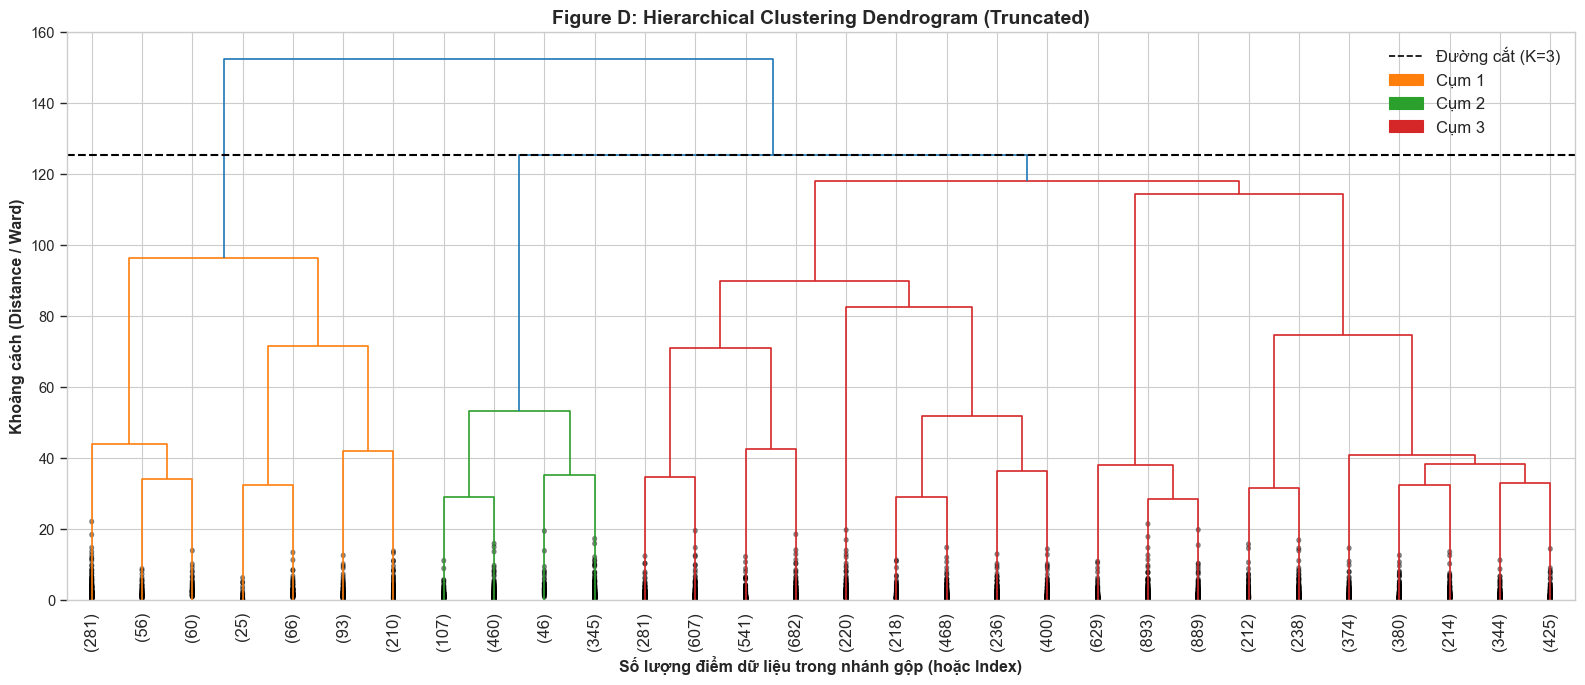

In [244]:
# =========================================
# BỔ SUNG: FIGURE D - DENDROGRAM (HIERARCHICAL CLUSTERING) CÓ LEGEND
# =========================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.cluster.hierarchy import dendrogram, linkage
import numpy as np

print("--- Generating Hierarchical Clustering Dendrogram ---")

# 1. Tính toán ma trận liên kết (linkage matrix)
Z = linkage(X_final, method='ward')

plt.figure(figsize=(16, 7))
plt.title("Figure D: Hierarchical Clustering Dendrogram (Truncated)", fontsize=14, fontweight='bold')

# 2. Tự động tìm ngưỡng cắt (Threshold) để tạo ra đúng K_COMPONENTS cụm (ở đây là 3)
K_COMPONENTS = 3
# Lấy khoảng cách của lần gộp thứ K từ trên xuống để làm mốc cắt
cut_threshold = Z[-(K_COMPONENTS-1), 2] - 0.0001 

# 3. Vẽ dendrogram và lưu kết quả trả về vào biến R để lấy màu
R = dendrogram(
    Z,
    truncate_mode='lastp',  
    p=30,                   
    leaf_rotation=90.,      
    leaf_font_size=12.,     
    show_contracted=True,
    color_threshold=cut_threshold # Ép tô màu theo mốc 3 cụm
)

# 4. Kẻ đường đứt nét biểu diễn vị trí cắt cụm
plt.axhline(y=cut_threshold, color='black', linestyle='--', linewidth=1.5)

# 5. Trích xuất màu sắc và Tạo Legend
# Scipy thường dùng màu 'C0' hoặc 'b' (blue) cho thân cây gốc, ta sẽ bỏ màu đó đi
trunk_colors = {'C0', 'b', 'k'} 
cluster_colors = sorted(list({c for c in R['color_list'] if c not in trunk_colors}))

# Tạo danh sách các icon cho Legend
legend_handles = [plt.Line2D([0], [0], color='black', linestyle='--', label=f'Đường cắt (K={K_COMPONENTS})')]

# Gắn từng màu với tên cụm tương ứng
for i, color in enumerate(cluster_colors):
    legend_handles.append(mpatches.Patch(color=color, label=f'Cụm {i+1}'))

# Hiển thị Legend
plt.legend(handles=legend_handles, loc='upper right', fontsize=12, framealpha=0.9, edgecolor='black')

plt.xlabel("Số lượng điểm dữ liệu trong nhánh gộp (hoặc Index)", fontweight='bold')
plt.ylabel("Khoảng cách (Distance / Ward)", fontweight='bold')
plt.tight_layout()

# Lưu biểu đồ
plt.savefig("figD_dendrogram_with_legend.png", dpi=150)
plt.show()
plt.close()

In [242]:
# 14. SAVE OUTPUTS TO CSV

In [243]:
print("--- 9. Saving Final CSVs ---")
df_metrics.to_csv("clustering_metrics_comparison.csv", index=False)

output_sample_df = X_original_sample.copy()
output_sample_df[f"{TARGET_COL}_true"] = y_true_final
for name, labels in model_labels.items():
    output_sample_df[f"label_{name.lower()}"] = labels

output_sample_df.to_excel("Du_Lieu_Tin_Dung_Da_Xu_Ly_Full.xlsx", index=False)

print("\nSUCCESS! All 8 images and 2 CSV files have been generated.")

--- 9. Saving Final CSVs ---

SUCCESS! All 8 images and 2 CSV files have been generated.
